# QCoDeS example with tinySA Basic

The [tinySA](https://www.tinysa.org/wiki/) is a USB-controlled spectrum analyser.
## Connect to the instrument
1. Make sure you have QCoDeS set up (see the [QCoDeS website](https://microsoft.github.io/Qcodes/index.html) or my notebook [14 minutes to QCoDeS](https://github.com/lairdgrouplancaster/14-minutes-to-QCoDeS/blob/main/14_minutes_to_QCoDeS.ipynb)).
2. In your `qcodes` environment, install [pyserial](https://pypi.org/project/pyserial/).
3. Plug the instrument into the USB interface of your computer and turn it on. A good testing configuration is to connect the `HIGH` input port to a signal generator set to 400 MHz and -10 dBm.
4. Run the following code, and check that you get a connect message.

In [1]:
import qcodes as qc
from qcodes_contrib_drivers.drivers.TinySA.basic import TinySABasic

qc.Instrument.close_all()
sa = TinySABasic("sa")
sa.get_idn()

Connected to: tinySA tinySA (serial:None, firmware:tinySA_v1.4-175-g1419a93) in 0.00s


{'vendor': 'tinySA',
 'model': 'tinySA',
 'serial': None,
 'firmware': 'tinySA_v1.4-175-g1419a93'}

## Initialise QCoDeS control

In [2]:
%matplotlib inline

import matplotlib.pyplot as plt

from qcodes.dataset import (
    Measurement,
    do0d,
    load_or_create_experiment,
    plot_by_id,
)

qc.initialise_or_create_database_at("./test_tinysa.db")
load_or_create_experiment(
    experiment_name="testing_tinySA",
    sample_name="signal_source",
)

testing_tinySA#signal_source#1@c:\Users\lairde\OneDrive - Lancaster University\Desktop\TinySA\Qcodes_contrib_drivers\docs\examples\test_tinysa.db
-------------------------------------------------------------------------------------------------------------------------------------------------

## Set up the instrument and make some measurements
The tinySA uses separate `low_input` and `high_input` measurement modes.
This example measures on the low input across 1 MHz to 300 MHz.
For measurements above about 250 MHz, switch to `sa.mode("high_input")`.
Output-generator modes are available as `low_output` and `high_output`, but they are not used in the measurement cells below.


Starting experimental run with id: 1. 


([<Axes: title={'center': 'Run #1, Experiment testing_tinySA (signal_source)'}, xlabel='Frequency (MHz)', ylabel='Measurement Trace (dBm)'>],
 [None])

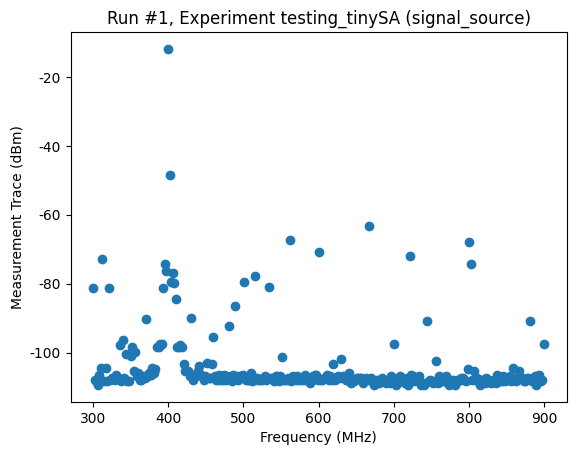

In [3]:
sa.mode("high_input")
sa.start(300e6)
sa.stop(900e6)
sa.points(290)
sa.rbw(300e3)

trace_dbm = sa.measurement_trace()
freq_hz = sa.frequency()

meas = Measurement()
meas.register_parameter(sa.frequency)
meas.register_parameter(sa.measurement_trace)

with meas.run() as datasaver:
    datasaver.add_result(
        (sa.frequency, freq_hz),
        (sa.measurement_trace, trace_dbm),
    )
    run_id = datasaver.run_id

plot_by_id(run_id)

## Do a fresh QCoDeS trace measurement
Calling `refresh_sweep()` before `do0d(...)` forces a new acquisition each time the cell is run.


Starting experimental run with id: 2. Using 'qcodes.dataset.do0d'


(results #2@c:\Users\lairde\OneDrive - Lancaster University\Desktop\TinySA\Qcodes_contrib_drivers\docs\examples\test_tinysa.db
 -----------------------------------------------------------------------------------------------------------------------------
 sa_frequency - array
 sa_measurement_trace - array,
 (<Axes: title={'center': 'Run #2, Experiment testing_tinySA (signal_source)'}, xlabel='Frequency (MHz)', ylabel='Measurement Trace (dBm)'>,),
 (None,))

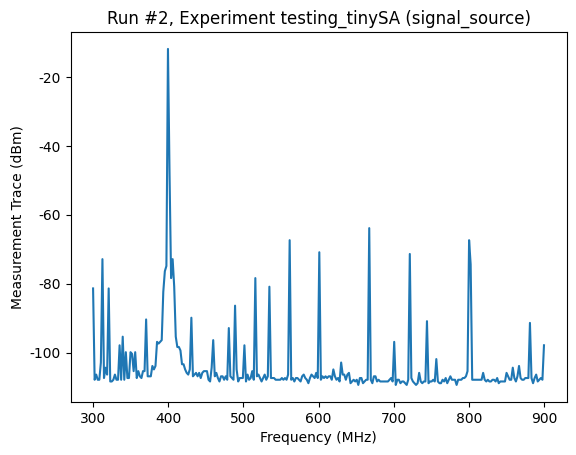

In [4]:
do0d(sa.measurement_trace, do_plot=True)

## Close the connection

In [5]:
sa.close()